Display Basic Information

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load dataset
df = pd.read_csv("D:/5th Sem/Machine Learning/ML Project/HairstylePredicAccordingToFaceshape/data sheets/synthetic_face_shape_dataset_5000.csv")

#Display basic info
df.head()

,forehead width (cm),jaw width (cm),face length (cm),face width (cm),face shape,best hairstyle
0,13.702252,12.724586,17.306009,14.490913,Square,Soft Curls
1,13.664632,13.359635,18.084700,13.225752,Diamond,Tousled Waves
2,14.718268,11.072230,18.924932,13.756551,Heart,Chin-Length Bob
3,14.194716,10.229002,18.447512,13.390788,Oval,Side Swept Bangs
4,14.674758,13.282522,18.614628,13.971958,Oblong,Curtain Bangs


Find Dataset shape, Null values and data types in the dataset

In [3]:
print("Shape of the dataset:", df.shape)
print("\nColumn Names:", df.columns.tolist())

#Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

#Data types
df.info()

Shape of the dataset: (5000, 6)

Column Names: ['forehead width (cm)', 'jaw width (cm)', 'face length (cm)', 'face width (cm)', 'face shape', 'best hairstyle']

Missing Values:
 forehead width (cm)    0
jaw width (cm)         0
face length (cm)       0
face width (cm)        0
face shape             0
best hairstyle         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   forehead width (cm)  5000 non-null   float64
 1   jaw width (cm)       5000 non-null   float64
 2   face length (cm)     5000 non-null   float64
 3   face width (cm)      5000 non-null   float64
 4   face shape           5000 non-null   object 
 5   best hairstyle       5000 non-null   object 
dtypes: float64(4), object(2)
memory usage: 234.5+ KB


Count of Each face shape

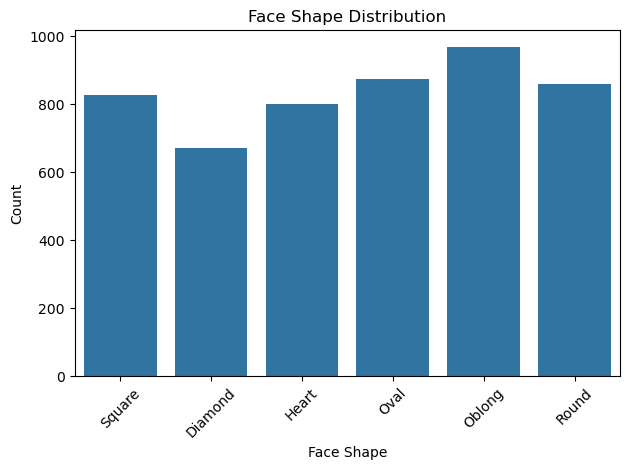

In [5]:
#Count of each face shape
sns.countplot(x='face shape', data=df)
plt.title('Face Shape Distribution')
plt.xlabel('Face Shape')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Feature Distribution by Face Shape
Analyze how each facial feature (face width, jaw width, forehead width, and chin length) varies across different face shape categories. The following boxplots help us observe the distribution for each feature with respect to the face shape classes.

Insights:

These plots help identify which features are more prominent or varying for specific face shapes.

For instance, if jaw_width is significantly higher in square face shapes compared to others, it could be an important feature for classification.

Outliers or overlapping ranges will also highlight challenges in separability among face shape classes.

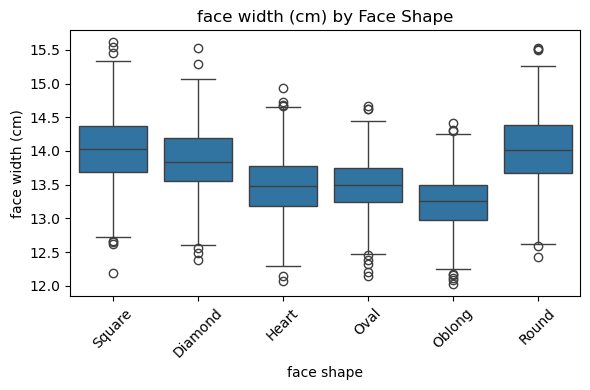

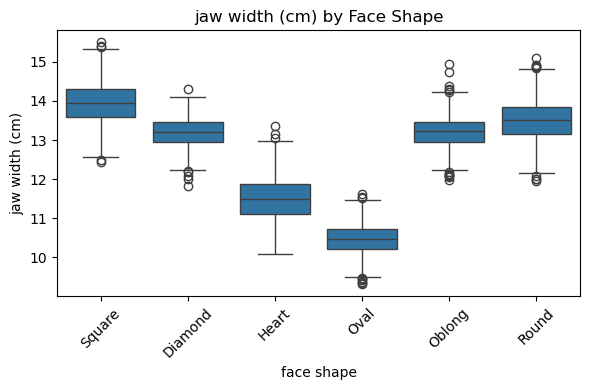

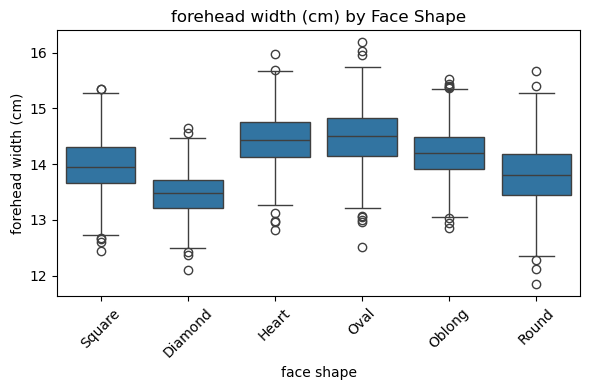

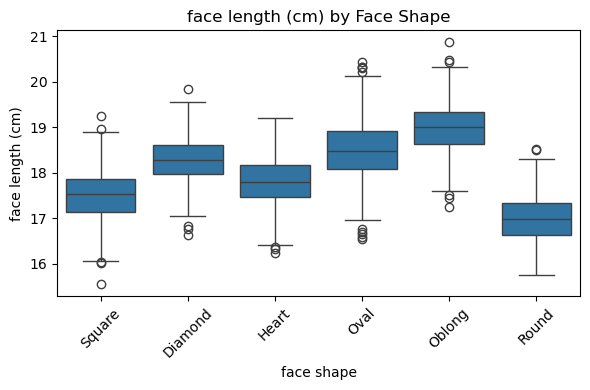

In [7]:
features = ['face width (cm)', 'jaw width (cm)', 'forehead width (cm)', 'face length (cm)']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='face shape', y=feature, data=df)
    plt.title(f'{feature} by Face Shape')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Observations:**
- `face_width` appears to be slightly larger in round and square faces.
- `jaw_width` shows clear distinction between square and round face shapes.

Distribution of Individual Facial Features
Analyze the distribution of each facial feature—face width, jaw width, forehead width, and face length—across the entire dataset. The following histograms help us understand:

The range and spread of each feature.

Whether the data is normally distributed, skewed, or contains outliers.

If feature scaling or normalization may be necessary for the model.

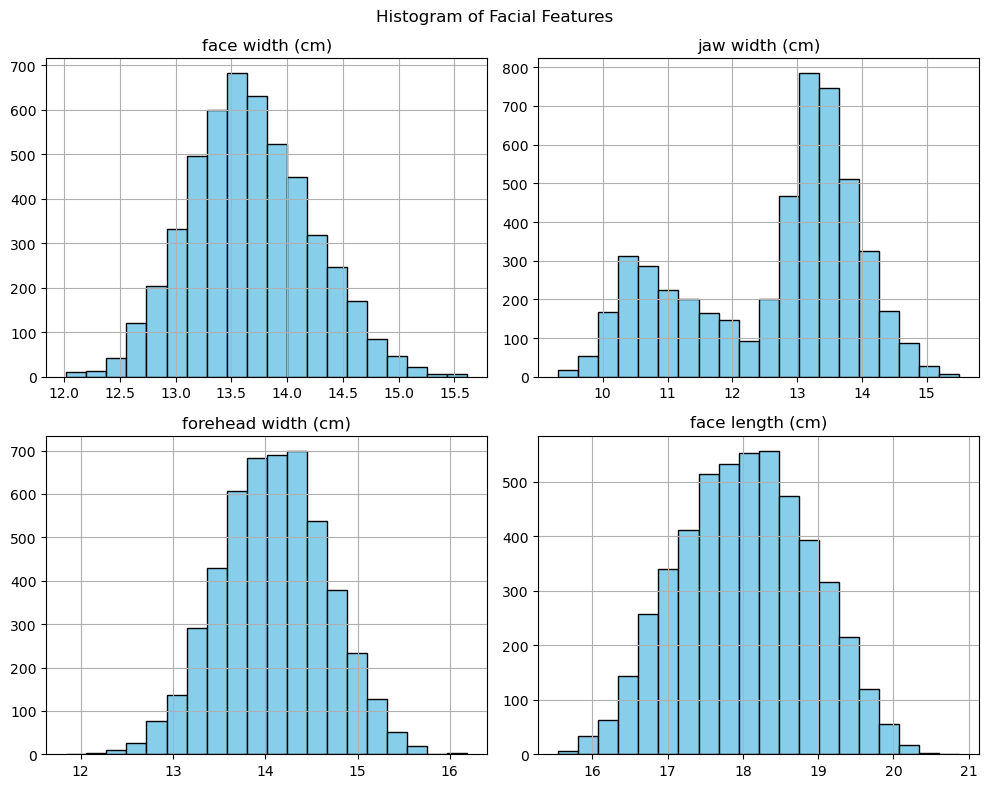

In [8]:
df[features].hist(bins=20, figsize=(10, 8), color='skyblue', edgecolor='black')
plt.suptitle('Histogram of Facial Features')
plt.tight_layout()
plt.show()


**Observations:**
- `face_width`  `forehead_width` `face_length` appear roughly normally distributed.
- `jaw_width` is slightly right-skewed, suggesting a few users with longer jaw widths
- The ranges of each feature differ, indicating the need for scaling before training the classifier.


Correlation Matrix of Facial Features
The correlation matrix below shows the pairwise linear relationships between the facial features: face width, jaw width, forehead width, and face length.

Why this is useful:

Helps detect multicollinearity — when two or more features are highly correlated.

Strong correlations (positive or negative) may indicate redundant information.

Features with low or no correlation can provide independent signals for classification models like SVM.

The values range from:

+1: Perfect positive correlation

0: No linear correlation

-1: Perfect negative correlation

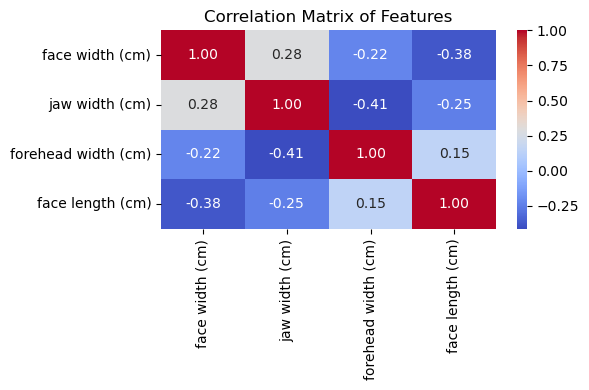

In [9]:
plt.figure(figsize=(6, 4))
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.tight_layout()
plt.show()


Pair Plot of Facial Features by Face Shape
The pair plot below visualizes the pairwise relationships between all facial features (face width, jaw width, forehead width, chin length) across different face shapes. It combines:

Scatter plots for feature pairs to show separation between face shape classes.

Histograms on the diagonal to show individual feature distributions.

Color coding by face_shape using the hue parameter.

Why this is useful:

Helps detect clusters, patterns, or overlaps between face shape categories.

Useful for identifying feature combinations that may separate classes well (important for classification).

Highlights relationships that may not be visible in individual histograms or boxplots.

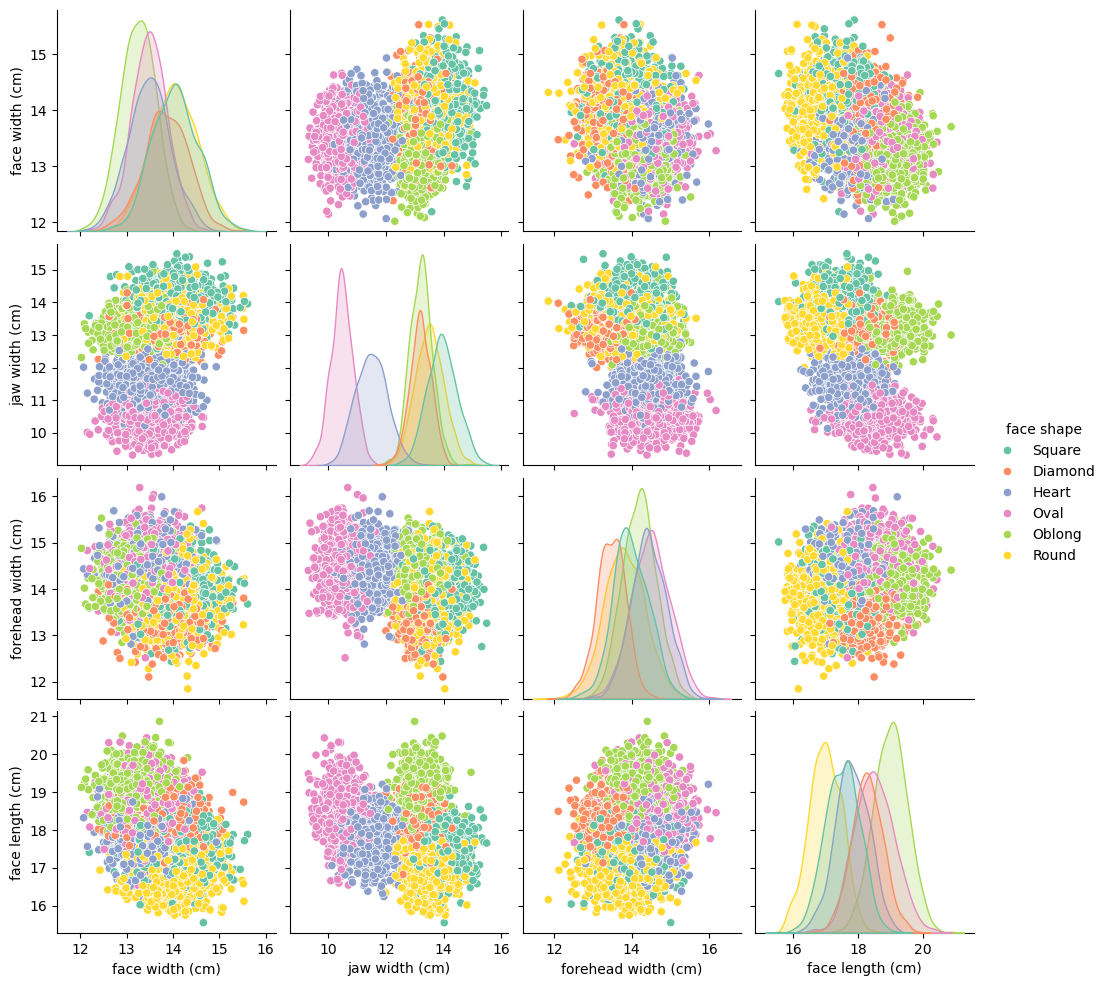

In [11]:
sns.pairplot(df, vars=features, hue='face shape', palette='Set2')
plt.show()


**Observations:**
- Some face shapes form distinguishable clusters in `jaw_width` vs `face_length`.
- There is notable overlap among face shapes for `forehead_width` and `face_width`, suggesting limited separation on those axes.
- Combining certain feature pairs might improve classification accuracy.
